# Bus Service Reliability Prediction Using BODS Timetable Data

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("BusServiceReliability")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

print("Spark Version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/02 00:05:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/02 00:05:19 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark Version: 4.1.1


In [2]:
import os

dataset_path = "../data/timetable"

print("Files in timetable folder:")
print(os.listdir(dataset_path))

Files in timetable folder:
['extracted', 'timetable.zip']


## Extract Dataset

In [3]:
import zipfile
import os

zip_path = "../data/timetable/timetable.zip"
extract_path = "../data/timetable/extracted"

# Create folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os

files = os.listdir("../data/timetable/extracted")

print("Number of extracted files:", len(files))
print(files[:10])  # Show the first 10 files

Number of extracted files: 123
['783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml', '717-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_537_20251023-BODS_V1_1.xml', 'PB726-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_560_20251023-BODS_V1_1.xml', '609-None--SCMY-RF-2026-03-29-Birkenhead_March_2026-Refresh2__SCMY_PC1033334_595_20260329-BODS_V1_1.xml', 'CH23-None--SCMY-CZ-2026-03-29-Chester_July_2026_(SchOut)__SCMY_PC1033334_628_20260719-BODS_V1_1.xml', '786-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_525_20251023-BODS_V1_1.xml', 'ME14-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_PC1033334_3_20260719-BODS_V1_1.xml', '708-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_536_20251023-BODS_V1_1.xml', '787-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_551_20251023-BODS_V1_1.xml', '

In [5]:
import os

folder = "../data/timetable/extracted"

first_file = os.listdir(folder)[0]

print(first_file)

783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml


In [6]:
with open(f"{folder}/{first_file}", "r", encoding="utf-8") as f:
    for i in range(50):
        print(f.readline().strip())

<?xml version='1.0' encoding='utf-8'?>
<!--Created by Optibus TransXChange Exporter (1.0.2)-->
<TransXChange xmlns="http://www.transxchange.org.uk/" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" CreationDateTime="2022-08-19T12:05:39" ModificationDateTime="2025-10-22T10:07:01" Modification="revise" RevisionNumber="1088" FileName="783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van-BODS_V1_1.xml" SchemaVersion="2.4" RegistrationDocument="false" xsi:schemaLocation="http://www.transxchange.org.uk/ http://www.transxchange.org.uk/schema/2.4/TransXChange_general.xsd">
<ServicedOrganisations>
<ServicedOrganisation>
<OrganisationCode>MYGM001</OrganisationCode>
<Name>Merseytravel Schools</Name>
<WorkingDays>
<DateRange>
<StartDate>2025-09-01</StartDate>
<EndDate>2025-10-24</EndDate>
<Description>Merseytravel Schools</Description>
</DateRange>
<DateRange>
<StartDate>2025-11-03</StartDate>
<EndDate>2025-12-19</EndDate>
<Description>Merseytravel Schools</Description>
</DateRange>


## Parse XML Files

In [7]:
import os
import xml.etree.ElementTree as ET

namespace = {
    "tx": "http://www.transxchange.org.uk/"
}

folder = "../data/timetable/extracted"

records = []


for file in os.listdir(folder):

    if not file.endswith(".xml"):
        continue

    path = os.path.join(folder, file)

    try:

        tree = ET.parse(path)
        root = tree.getroot()


        operator = root.find(
            ".//tx:OperatorShortName",
            namespace
        )

        if operator is None:
            operator = root.find(
                ".//tx:OperatorNameOnLicence",
                namespace
            )


        service_code = root.find(
            ".//tx:ServiceCode",
            namespace
        )


        journeys = root.findall(
            ".//tx:VehicleJourney",
            namespace
        )


        for journey in journeys:

            journey_id = journey.find(
                "tx:VehicleJourneyCode",
                namespace
            )


            timing_links = journey.findall(
                "tx:VehicleJourneyTimingLink",
                namespace
            )


            for sequence, link in enumerate(timing_links):

                records.append({

                    "filename": file,

                    "journey_id":
                    journey_id.text
                    if journey_id is not None else None,

                    "operator":
                    operator.text
                    if operator is not None else None,

                    "service_code":
                    service_code.text
                    if service_code is not None else None,

                    "stop_sequence":
                    sequence + 1
                })


    except Exception as e:
        print(file, e)


print("Total records:", len(records))

Total records: 271552


In [8]:
print(len(records))

271552


## Create Spark DataFrame

In [10]:
df = spark.createDataFrame(records)

print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

df.show(10, truncate=False)

df.printSchema()

Number of rows: 271552
Number of columns: 5
+--------------------------------------------------------------------------------------------------------+----------+----------+-------------+-------------+
|filename                                                                                                |journey_id|operator  |service_code |stop_sequence|
+--------------------------------------------------------------------------------------------------------+----------+----------+-------------+-------------+
|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml|VJ3622    |Stagecoach|PC1033334:549|1            |
|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml|VJ3622    |Stagecoach|PC1033334:549|2            |
|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml|VJ3622    |Stagecoach|PC1033334:549|3            |
|783-None--SCM

Traceback (most recent call last):
  File "/home/uvica/spark_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/uvica/spark_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


In [11]:
df.printSchema()

root
 |-- filename: string (nullable = true)
 |-- journey_id: string (nullable = true)
 |-- operator: string (nullable = true)
 |-- service_code: string (nullable = true)
 |-- stop_sequence: long (nullable = true)



In [12]:
print("Total records:", df.count())

[Stage 5:=================================>                        (7 + 5) / 12]

Total records: 271552


In [13]:
print("Number of columns:", len(df.columns))

Number of columns: 5


In [14]:
print(df.columns)

['filename', 'journey_id', 'operator', 'service_code', 'stop_sequence']


In [15]:
from pyspark.sql.functions import col, sum

df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

[Stage 8:========================>                                 (5 + 7) / 12]

+--------+----------+--------+------------+-------------+
|filename|journey_id|operator|service_code|stop_sequence|
+--------+----------+--------+------------+-------------+
|       0|         0|       0|           0|            0|
+--------+----------+--------+------------+-------------+



In [16]:
import xml.etree.ElementTree as ET

tree = ET.parse("../data/timetable/extracted/" + first_file)
root = tree.getroot()

namespace = {"tx": "http://www.transxchange.org.uk/"}

for child in root:
    print(child.tag)

{http://www.transxchange.org.uk/}ServicedOrganisations
{http://www.transxchange.org.uk/}StopPoints
{http://www.transxchange.org.uk/}RouteSections
{http://www.transxchange.org.uk/}Routes
{http://www.transxchange.org.uk/}JourneyPatternSections
{http://www.transxchange.org.uk/}Operators
{http://www.transxchange.org.uk/}Services
{http://www.transxchange.org.uk/}VehicleJourneys


In [17]:
import os
import xml.etree.ElementTree as ET

folder = "../data/timetable/extracted"

records = []

namespace = {
    "tx": "http://www.transxchange.org.uk/"
}


for file in os.listdir(folder):

    if not file.endswith(".xml"):
        continue

    filepath = os.path.join(folder, file)

    try:
        tree = ET.parse(filepath)
        root = tree.getroot()

        operator = root.find(
            ".//tx:OperatorShortName",
            namespace
        )

        if operator is None:
            operator = root.find(
                ".//tx:OperatorNameOnLicence",
                namespace
            )

        service_code = root.find(
            ".//tx:ServiceCode",
            namespace
        )

        journeys = root.findall(
            ".//tx:VehicleJourney",
            namespace
        )


        for journey in journeys:

            journey_id = journey.find(
                "tx:VehicleJourneyCode",
                namespace
            )

            timing_links = journey.findall(
                "tx:VehicleJourneyTimingLink",
                namespace
            )


            for sequence, link in enumerate(timing_links):

                records.append({

                    "filename": file,

                    "operator":
                    operator.text if operator is not None else None,

                    "service_code":
                    service_code.text if service_code is not None else None,

                    "journey_id":
                    journey_id.text if journey_id is not None else None,

                    "stop_sequence":
                    sequence + 1
                })


    except Exception as e:
        print(file, e)


print("Total records:", len(records))

Total records: 271552


In [18]:
df = spark.createDataFrame(records)

print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

df.show(10, truncate=False)

df.printSchema()

Number of rows: 271552
Number of columns: 5
+--------------------------------------------------------------------------------------------------------+----------+----------+-------------+-------------+
|filename                                                                                                |journey_id|operator  |service_code |stop_sequence|
+--------------------------------------------------------------------------------------------------------+----------+----------+-------------+-------------+
|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml|VJ3622    |Stagecoach|PC1033334:549|1            |
|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml|VJ3622    |Stagecoach|PC1033334:549|2            |
|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml|VJ3622    |Stagecoach|PC1033334:549|3            |
|783-None--SCM

Traceback (most recent call last):
  File "/home/uvica/spark_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/uvica/spark_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


In [19]:
df.printSchema()

root
 |-- filename: string (nullable = true)
 |-- journey_id: string (nullable = true)
 |-- operator: string (nullable = true)
 |-- service_code: string (nullable = true)
 |-- stop_sequence: long (nullable = true)



In [19]:
df.describe().show()

26/08/01 22:49:43 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 9:>                                                        (0 + 12) / 12]

+-------+-------------------+--------------------+------------------+-------------------+------------------+-----------------+----------+--------------------+-------------+
|summary|      creation_time|            filename|         line_name|      modified_time|number_of_journeys|  number_of_stops|  operator|   route_description| service_code|
+-------+-------------------+--------------------+------------------+-------------------+------------------+-----------------+----------+--------------------+-------------+
|  count|                123|                 123|               123|                123|               123|              123|       123|                 123|          123|
|   mean|               NULL|                NULL| 512.7017543859649|               NULL| 55.82113821138211| 62.9349593495935|      NULL|                NULL|         NULL|
| stddev|               NULL|                NULL|312.18873148736697|               NULL|110.08044990438981|49.09037163740293|      NUL

In [20]:
df.show(10, truncate=False)

+--------------------------------------------------------------------------------------------------------+----------+----------+-------------+-------------+
|filename                                                                                                |journey_id|operator  |service_code |stop_sequence|
+--------------------------------------------------------------------------------------------------------+----------+----------+-------------+-------------+
|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml|VJ3622    |Stagecoach|PC1033334:549|1            |
|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml|VJ3622    |Stagecoach|PC1033334:549|2            |
|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml|VJ3622    |Stagecoach|PC1033334:549|3            |
|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE

Traceback (most recent call last):
  File "/home/uvica/spark_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/uvica/spark_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


## Exploratory Data Analysis (EDA)

In [21]:
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Number of rows: 271552
Number of columns: 5


In [22]:
print(df.columns)

['filename', 'journey_id', 'operator', 'service_code', 'stop_sequence']


In [23]:
from pyspark.sql.functions import col, sum

missing = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

missing.show()

[Stage 19:==============>                                          (3 + 9) / 12]

+--------+----------+--------+------------+-------------+
|filename|journey_id|operator|service_code|stop_sequence|
+--------+----------+--------+------------+-------------+
|       0|         0|       0|           0|            0|
+--------+----------+--------+------------+-------------+



In [31]:
df.describe().show()

[Stage 37:==========================================>              (9 + 3) / 12]

+-------+--------------------+----------+----------+-------------+------------------+
|summary|            filename|journey_id|  operator| service_code|     stop_sequence|
+-------+--------------------+----------+----------+-------------+------------------+
|  count|              271552|    271552|    271552|       271552|            271552|
|   mean|                NULL|      NULL|      NULL|         NULL|26.025019149186896|
| stddev|                NULL|      NULL|      NULL|         NULL|19.763537454464057|
|    min|10A-None--SCMY-GM...|       VJ1|Stagecoach|PC1033334:106|                 1|
|    max|X725-None--SCMY-G...|     VJ999|Stagecoach| PC1033334:67|               114|
+-------+--------------------+----------+----------+-------------+------------------+



In [25]:
from pyspark.sql.functions import desc

df.groupBy("operator") \
  .count() \
  .orderBy(desc("count")) \
  .show(10)

[Stage 25:=================================>                       (7 + 5) / 12]

+----------+------+
|  operator| count|
+----------+------+
|Stagecoach|271552|
+----------+------+



In [26]:
df.groupBy("service_code") \
  .count() \
  .orderBy(desc("count")) \
  .show(10)

[Stage 28:==============>                                          (3 + 9) / 12]

+-------------+-----+
| service_code|count|
+-------------+-----+
| PC1033334:15|27825|
|PC1033334:196|20262|
|PC1033334:186|18095|
|  PC1033334:5|18007|
| PC1033334:12|15256|
|PC1033334:120|14808|
|PC1033334:185|14562|
|PC1033334:106|14110|
| PC1033334:14|12139|
|  PC1033334:3|11735|
+-------------+-----+
only showing top 10 rows


## Visualization 1: Top 10 Routes by Number of Stops

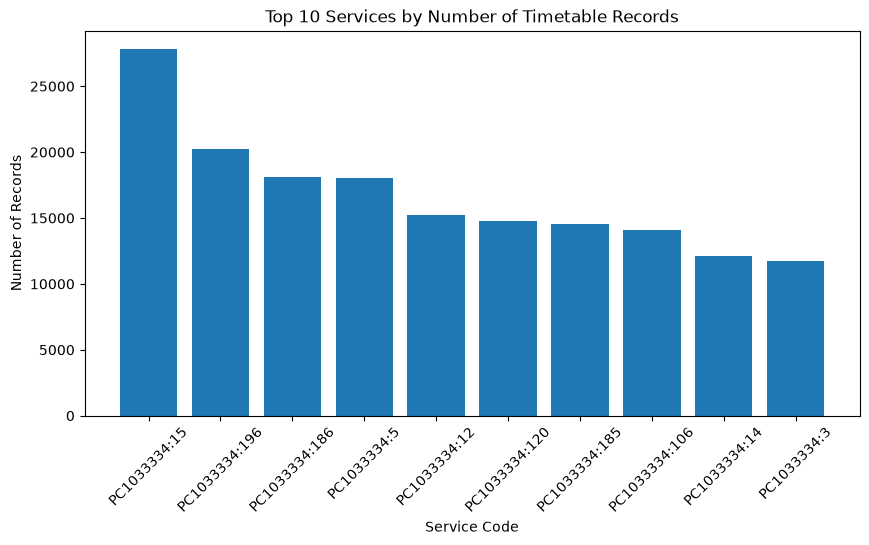

In [27]:
import matplotlib.pyplot as plt

top_services = (
    df.groupBy("service_code")
      .count()
      .orderBy(desc("count"))
      .limit(10)
      .toPandas()
)

plt.figure(figsize=(10,5))

plt.bar(
    top_services["service_code"],
    top_services["count"]
)

plt.title("Top 10 Services by Number of Timetable Records")
plt.xlabel("Service Code")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.show()

## Save Processed Data

In [28]:
df.write.mode("overwrite").parquet("../outputs/timetable_parquet")

26/08/02 00:11:03 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/08/02 00:11:03 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/08/02 00:11:03 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/08/02 00:11:03 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/08/02 00:11:03 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/08/02 00:11:05 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/08/02 00:11:05 WARN MemoryManager: Total allocation exceeds 95.

In [29]:
import os

print(os.listdir("../outputs"))

['models', 'cleaned_timetable_parquet', 'timetable_parquet', 'figures', 'tables']


In [30]:
saved_df = spark.read.parquet("../outputs/timetable_parquet")

saved_df.show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------+----------+----------+------------+-------------+
|filename                                                                                               |journey_id|operator  |service_code|stop_sequence|
+-------------------------------------------------------------------------------------------------------+----------+----------+------------+-------------+
|10A-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_PC1033334_5_20260719-BODS_V1_1.xml|VJ2904    |Stagecoach|PC1033334:5 |55           |
|10A-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_PC1033334_5_20260719-BODS_V1_1.xml|VJ2904    |Stagecoach|PC1033334:5 |56           |
|10A-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_PC1033334_5_20260719-BODS_V1_1.xml|VJ2904    |Stagecoach|PC1033334:5 |57           |
|10A-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_

## Summary

In this notebook:

- Loaded the BODS timetable dataset.
- Extracted XML timetable files.
- Parsed relevant transport information from each XML file.
- Created a PySpark DataFrame.
- Performed exploratory data analysis.
- Generated visualizations.
- Saved the processed dataset in Parquet format.